In [9]:
# CELL 1: Setup
import sys
sys.path.append('..')
from shared.data_loader import get_revenue_by_period
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

print('✅ Setup complete')

✅ Setup complete


In [11]:
# CELL 2: Load data
df = get_revenue_by_period()
print(f'Loaded {len(df)} rows')
print(f'Brands: {df["brand_name"].unique()}')
print(df.head(10))

Loaded 81 rows
Brands: <StringArray>
['SPECS', 'PIERO', 'MINERAL BOTANICAL', 'FISIK SPORT', 'C&F']
Length: 5, dtype: str
                               brand_id brand_name  period_id  total_revenue  \
0  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          1    284360531.0   
1  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          2    384641036.0   
2  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          3    594435611.0   
3  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          4    295376089.0   
4  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          5    261723638.0   
5  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          6    194295617.0   
6  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          7    475388697.0   
7  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          8    264702270.0   
8  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS          9    603882878.0   
9  25cefaec-b9b3-4a0a-9858-0e166ac03b01      SPECS         10    675893306.0   

In [17]:
# CHECK: Is Period 12 really zero, or is data missing?
import sys
sys.path.append('..')
from shared.supabase_client import fetch_all

# Look at raw C&F sessions for Period 12
sessions = fetch_all('live_sessions')
c_period12 = sessions[(sessions['brand_id'] == 'f6385739-fd01-4e15-8cc0-ff2b5102c506') & 
                       (sessions['period_id'] == 12)]

print(f'C&F Period 12: {len(c_period12)} sessions found')
if len(c_period12) > 0:
    print(f'Total Shopee Revenue: Rp {c_period12["revenue_shopee"].sum():,.0f}')
    print(f'Total TikTok Revenue: Rp {c_period12["revenue_tiktok"].sum():,.0f}')
    print(f'Sample dates: {c_period12["date"].unique()[:5]}')
else:
    print('⚠️  No sessions found for C&F Period 12!')
    print('   This period might not have happened yet, or data is missing.')

C&F Period 12: 461 sessions found
Total Shopee Revenue: Rp 0
Total TikTok Revenue: Rp 0
Sample dates: <StringArray>
['2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04', '2026-05-05']
Length: 5, dtype: str


In [16]:
# CELL 3 — RECOMMENDED VERSION (Fix 1 + Fix 2)
from sklearn.linear_model import LinearRegression
import numpy as np

def forecast_brand_final(df, brand_name, lookback=6):
    brand_df = df[df['brand_name'] == brand_name].sort_values('period_id')
    
    if len(brand_df) < 2:
        return None, None, None
    
    # FIX 1: Smooth with 3-period rolling average
    brand_df = brand_df.copy()
    brand_df['smoothed'] = brand_df['total_revenue'].rolling(window=3, min_periods=1).mean()
    
    # FIX 2: Only use most recent periods
    brand_df = brand_df.tail(lookback)
    
    X = brand_df['period_id'].values.reshape(-1, 1)
    y = brand_df['smoothed'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    next_period = brand_df['period_id'].max() + 1
    prediction = max(0, model.predict([[next_period]])[0])
    
    r2 = model.score(X, y)
    mae = np.mean(np.abs(y - model.predict(X)))
    
    if r2 > 0.5:
        quality = "✅ Good fit"
    elif r2 > 0.2:
        quality = "⚠️ Moderate fit"
    else:
        quality = "❌ Poor fit"
    
    trend = "⬆️ Growing" if model.coef_[0] > 0 else "⬇️ Declining"
    
    print(f'\n{brand_name}:')
    print(f'  R² Score: {r2:.3f} ({quality})')
    print(f'  Avg Error: Rp {mae:,.0f}')
    print(f'  Trend: {trend}')
    print(f'  Next period ({next_period}): Rp {prediction:,.0f}')
    
    return model, prediction, r2

# Forecast for all brands
results = {}
for brand in df['brand_name'].unique():
    model, pred, r2 = forecast_brand_final(df, brand)
    results[brand] = {'model': model, 'prediction': pred, 'r2': r2}

print('\n✅ Forecasting complete!')
# ============================================================
# BETTER C&F HANDLING
# ============================================================
print('\n--- Fixing C&F ---')

c_df = df[df['brand_name'] == 'C&F'].sort_values('period_id')

# Check if last period is zero (likely incomplete data)
if c_df['total_revenue'].iloc[-1] == 0:
    print('⚠️  Period 12 has Rp 0 — likely incomplete/not recorded')
    print('   Using periods 9-10-11 instead of 10-11-12')
    
    # Use periods that actually have revenue
    c_df_real = c_df[c_df['total_revenue'] > 0]
    last_3_avg = c_df_real['total_revenue'].tail(3).mean()
    
    for _, row in c_df_real.tail(3).iterrows():
        print(f'  Period {int(row["period_id"])}: Rp {row["total_revenue"]:,.0f}')
else:
    last_3_avg = c_df['total_revenue'].tail(3).mean()

print(f'  Prediction: Rp {last_3_avg:,.0f}')
results['C&F']['prediction'] = last_3_avg


SPECS:
  R² Score: 0.672 (✅ Good fit)
  Avg Error: Rp 83,450,686
  Trend: ⬇️ Declining
  Next period (22): Rp 289,095,397

PIERO:
  R² Score: 0.915 (✅ Good fit)
  Avg Error: Rp 7,733,430
  Trend: ⬇️ Declining
  Next period (26): Rp 47,303,862

MINERAL BOTANICAL:
  R² Score: 0.678 (✅ Good fit)
  Avg Error: Rp 25,825,750
  Trend: ⬇️ Declining
  Next period (10): Rp 145,353,460

FISIK SPORT:
  R² Score: 0.946 (✅ Good fit)
  Avg Error: Rp 6,869,985
  Trend: ⬇️ Declining
  Next period (15): Rp 24,830,801

C&F:
  R² Score: 0.089 (❌ Poor fit)
  Avg Error: Rp 81,420,946
  Trend: ⬆️ Growing
  Next period (13): Rp 413,954,398

✅ Forecasting complete!

--- Fixing C&F ---
⚠️  Period 12 has Rp 0 — likely incomplete/not recorded
   Using periods 9-10-11 instead of 10-11-12
  Period 9: Rp 687,823,172
  Period 10: Rp 482,233,527
  Period 11: Rp 291,960,867
  Prediction: Rp 487,339,189


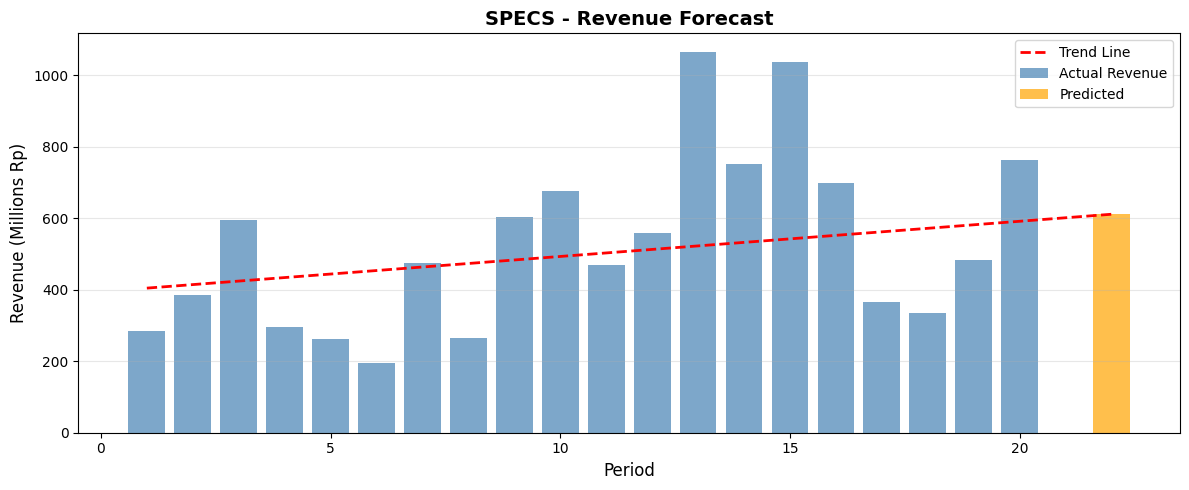

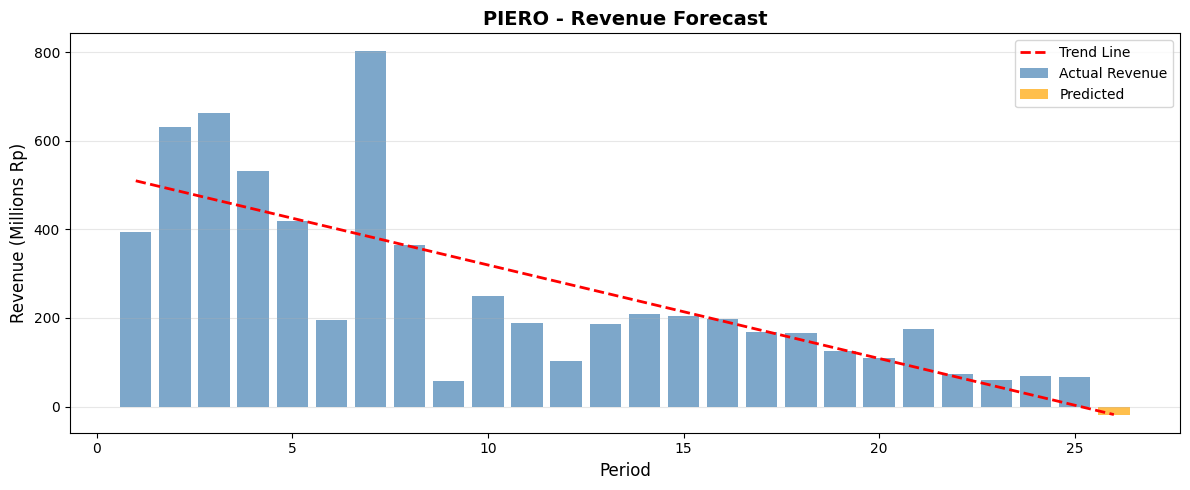

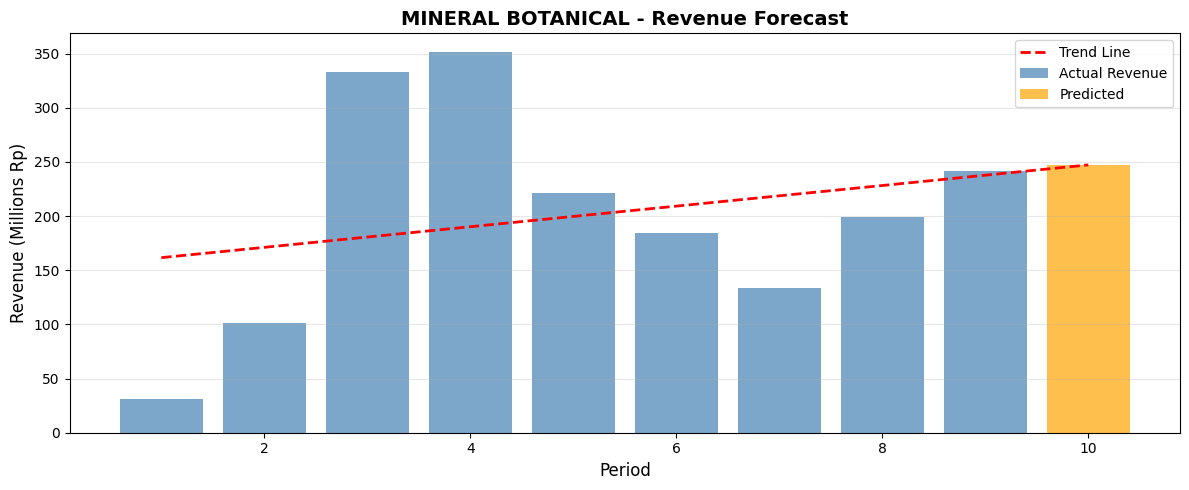

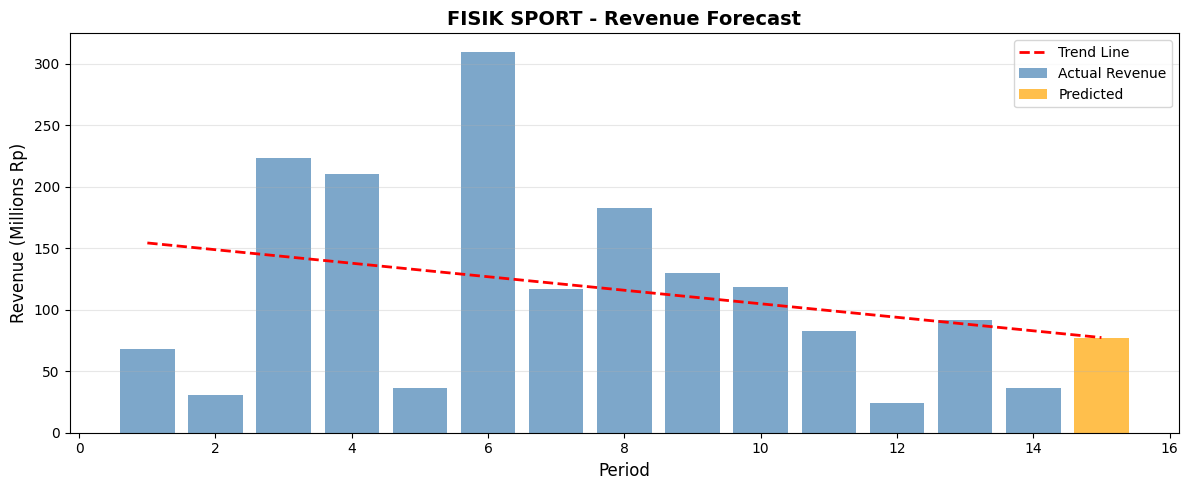

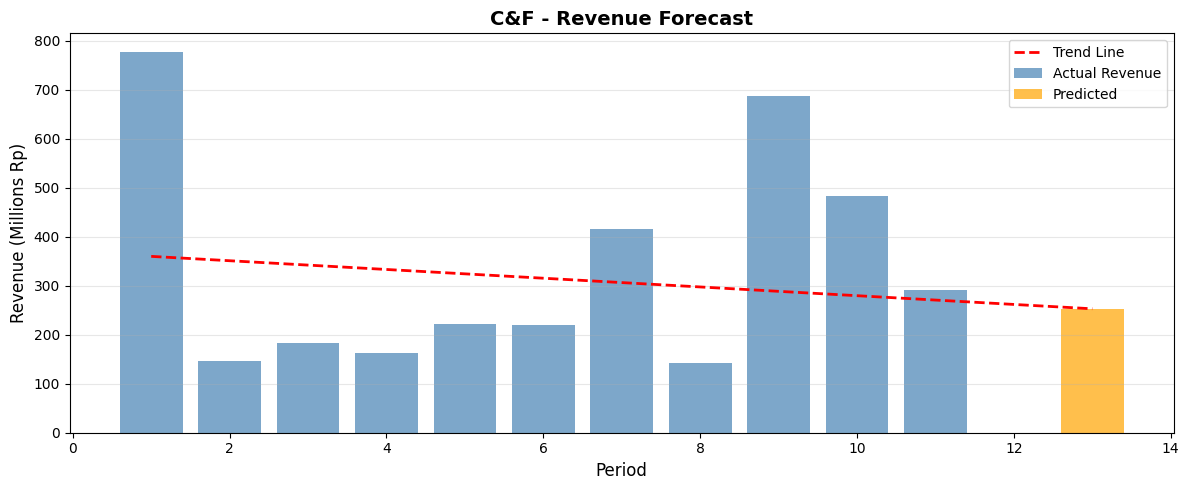

In [5]:
# CELL 4: Visualize Actual vs Predicted
import matplotlib.pyplot as plt

def plot_brand(df, brand_name, results):
    brand_df = df[df['brand_name'] == brand_name].sort_values('period_id')
    X = brand_df['period_id'].values.reshape(-1, 1)
    y = brand_df['total_revenue'].values
    
    model = results[brand_name]['model']
    if model is None:
        return
    
    next_p = brand_df['period_id'].max() + 1
    all_X = np.arange(brand_df['period_id'].min(), next_p + 1).reshape(-1, 1)
    predictions = model.predict(all_X)
    
    plt.figure(figsize=(12, 5))
    
    # Actual bars
    plt.bar(brand_df['period_id'], y / 1e6, color='steelblue', alpha=0.7, label='Actual Revenue')
    
    # Trend line
    plt.plot(all_X, predictions / 1e6, 'r--', linewidth=2, label='Trend Line')
    
    # Next period prediction
    plt.bar(next_p, predictions[-1] / 1e6, color='orange', alpha=0.7, label='Predicted')
    
    plt.title(f'{brand_name} - Revenue Forecast', fontsize=14, fontweight='bold')
    plt.xlabel('Period', fontsize=12)
    plt.ylabel('Revenue (Millions Rp)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot all brands
for brand in df['brand_name'].unique():
    plot_brand(df, brand, results)

In [6]:
# CELL 5: Summary Table
summary_data = []
for brand in df['brand_name'].unique():
    if results[brand]['model'] is not None:
        r2 = results[brand]['model'].score(
            df[df['brand_name'] == brand]['period_id'].values.reshape(-1, 1),
            df[df['brand_name'] == brand]['total_revenue'].values
        )
        trend = '⬆️ Growing' if results[brand]['model'].coef_[0] > 0 else '⬇️ Declining'
        summary_data.append({
            'Brand': brand,
            'Periods': len(df[df['brand_name'] == brand]),
            'R² Score': f'{r2:.3f}',
            'Trend': trend,
            'Next Period Prediction': f'Rp {results[brand]["prediction"]:,.0f}'
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

            Brand  Periods R² Score        Trend Next Period Prediction
            SPECS       21    0.052   ⬆️ Growing         Rp 610,766,130
            PIERO       25    0.566 ⬇️ Declining         Rp -18,183,898
MINERAL BOTANICAL        9    0.063   ⬆️ Growing         Rp 247,308,105
      FISIK SPORT       14    0.072 ⬇️ Declining          Rp 77,329,628
              C&F       12    0.019 ⬇️ Declining         Rp 252,947,947


In [7]:
# CELL 6: Save predictions to revenue_predictions table
import sys
sys.path.append('..')
from shared.supabase_client import get_client
from datetime import datetime

supabase = get_client()

saved_count = 0
for brand in df['brand_name'].unique():
    if results[brand]['model'] is None:
        continue
    
    brand_df = df[df['brand_name'] == brand].sort_values('period_id')
    model = results[brand]['model']
    
    # Get the last date for this brand
    X_all = brand_df['period_id'].values.reshape(-1, 1)
    y_all = brand_df['total_revenue'].values
    
    for i, (period, actual) in enumerate(zip(brand_df['period_id'], y_all)):
        # Insert actual data
        supabase.table('revenue_predictions').insert({
            'period_id': int(period),
            'period_name': f'Period {int(period)}',
            'date': datetime.now().date().isoformat(),
            'actual': int(actual),
            'predicted': int(model.predict([[period]])[0]),
            'is_future': False,
            'model_r2': float(model.score(X_all, y_all)),
            'model_mae': float(np.mean(np.abs(y_all - model.predict(X_all)))),
            'model_slope': float(model.coef_[0]),
        }).execute()
        saved_count += 1
    
    # Insert future prediction
    next_period = brand_df['period_id'].max() + 1
    supabase.table('revenue_predictions').insert({
        'period_id': int(next_period),
        'period_name': f'Period {int(next_period)}',
        'date': datetime.now().date().isoformat(),
        'actual': None,
        'predicted': int(results[brand]['prediction']),
        'is_future': True,
        'model_r2': float(model.score(X_all, y_all)),
        'model_mae': float(np.mean(np.abs(y_all - model.predict(X_all)))),
        'model_slope': float(model.coef_[0]),
    }).execute()
    saved_count += 1

print(f'✅ Saved {saved_count} predictions to database!')

✅ Saved 86 predictions to database!


In [8]:
# CELL 7: Dashboard Summary
print('=' * 60)
print('📊 VIDHELP ADMIN DASHBOARD - REVENUE FORECAST')
print('=' * 60)

for brand in df['brand_name'].unique():
    if results[brand]['model'] is None:
        continue
    
    model = results[brand]['model']
    X = df[df['brand_name'] == brand]['period_id'].values.reshape(-1, 1)
    y = df[df['brand_name'] == brand]['total_revenue'].values
    
    actual_last = y[-1]
    predicted_next = results[brand]['prediction']
    pct_change = ((predicted_next - actual_last) / actual_last) * 100
    
    trend_icon = '📈' if pct_change > 0 else '📉'
    
    print(f'\n{trend_icon} {brand}')
    print(f'   Current Revenue : Rp {actual_last:,.0f}')
    print(f'   Next Period     : Rp {predicted_next:,.0f}')
    print(f'   Change          : {pct_change:+.1f}%')
    print(f'   Model R²        : {model.score(X, y):.3f}')
    print(f'   Trend           : {"Growing" if model.coef_[0] > 0 else "Declining"}')

print('\n' + '=' * 60)
print('✅ Forecasting engine complete — predictions saved to database')

📊 VIDHELP ADMIN DASHBOARD - REVENUE FORECAST

📈 SPECS
   Current Revenue : Rp 0
   Next Period     : Rp 610,766,130
   Change          : +inf%
   Model R²        : 0.052
   Trend           : Growing

📉 PIERO
   Current Revenue : Rp 65,639,355
   Next Period     : Rp -18,183,898
   Change          : -127.7%
   Model R²        : 0.566
   Trend           : Declining

📈 MINERAL BOTANICAL
   Current Revenue : Rp 241,930,755
   Next Period     : Rp 247,308,105
   Change          : +2.2%
   Model R²        : 0.063
   Trend           : Growing

📈 FISIK SPORT
   Current Revenue : Rp 36,005,167
   Next Period     : Rp 77,329,628
   Change          : +114.8%
   Model R²        : 0.072
   Trend           : Declining

📈 C&F
   Current Revenue : Rp 0
   Next Period     : Rp 252,947,947
   Change          : +inf%
   Model R²        : 0.019
   Trend           : Declining

✅ Forecasting engine complete — predictions saved to database


C:\Users\dadia\AppData\Local\Temp\ipykernel_4576\3463979668.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  pct_change = ((predicted_next - actual_last) / actual_last) * 100
C:\Users\dadia\AppData\Local\Temp\ipykernel_4576\3463979668.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  pct_change = ((predicted_next - actual_last) / actual_last) * 100
